In [85]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.table import Table

import pandas as pd
import pyStarlet_master_2D1D as pys


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from matplotlib.colors import LogNorm

import torch

Numba imported


## Load in data ##

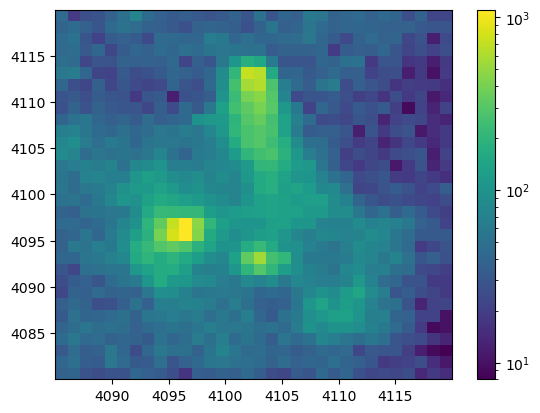

In [2]:
## Load the data into a pandas DataFrame

EVT_FILE = 'acisi_merged.fits'
hdu = fits.open(EVT_FILE)
evt_data = hdu[1].data

cols = ['energy', 'x', 'y', 'ccd_id']
df = Table([evt_data[c] for c in cols], names=cols).to_pandas()

XMIN = 4085
XMAX = 4120
YMIN = 4080
YMAX = 4120

subset = df[(df['x'] > XMIN) & (df['x'] < XMAX) & \
            (df['y'] > YMIN) & (df['y'] < YMAX) & \
            (df['energy'] > 2000) & (df['energy'] < 8000)]

BINX = 32
BINY = 32
BINE = 50

_ = plt.hist2d(subset['x'], subset['y'], bins=(BINX, BINY), cmap='viridis', norm=LogNorm())
plt.colorbar()

In [3]:
## Get low energy subset
EMIN = 2000
EMAX = 5500
low_e_subset = df[(df['x'] > XMIN) & (df['x'] < XMAX) & \
            (df['y'] > YMIN) & (df['y'] < YMAX) & \
            (df['energy'] > EMIN) & (df['energy'] < EMAX)]


## Spectral Cube ##

In [165]:
spectral_cube, _ = np.histogramdd(low_e_subset[['energy', 'x', 'y']].values, bins=(BINE, BINX, BINY))
print(spectral_cube.shape)

# Convert the spectral cube to a PyTorch tensor
spectral_cube_tensor = torch.tensor(spectral_cube, dtype=torch.float32)

(50, 32, 32)


torch.Size([50, 32, 50])


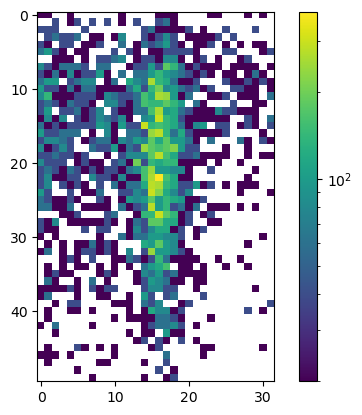

In [58]:
import torch.nn as nn

## Hold on to this for now -- for use with pytorch
class SpectralImageModel(nn.Module):
    def __init__(self, bins_2d, bins_1d):
        super().__init__()
        # No learnable parameters, just a functional model
        self.bins_2d = bins_2d
        self.bins_1d = bins_1d

    def forward(self, image_2d, spectrum_1d):
        # image_2d: shape (bins_2d, bins_2d)
        # spectrum_1d: shape (bins_1d,)
        # Output: shape (bins_2d, bins_2d, bins_1d)
        # Outer product: each pixel in image_2d multiplies the whole spectrum
        return image_2d.unsqueeze(-1) * spectrum_1d
    
def spectral_image_model(image_2d, spectrum_1d):
    """
    Create a spectral image model that combines a 2D image with a 1D spectrum.
    
    Parameters:
    - image_2d: A 2D tensor representing the image.
    - spectrum_1d: A 1D tensor representing the spectrum.
    
    Returns:
    - A 3D tensor where each pixel in the 2D image is multiplied by the 1D spectrum.
    """
    model = spectrum_1d * image_2d.unsqueeze(-1)
    return model

# Example usage:
# model = SpectralImageModel(BINNING, BINNING)
# output_cube = model(image_2d, spectrum_1d)

spectrum_1d = torch.tensor(np.arange(BINE), dtype=torch.float32)  # Example spectrum, replace with actual data
image_2d = torch.tensor(spectral_cube[:,:,20], dtype=torch.float32)  # Example image, replace with actual data
model_cube = spectral_image_model(image_2d, spectrum_1d)

i = 20
print(model_cube.shape)
plt.imshow(model_cube[:, :, i].numpy(), cmap='viridis', norm=LogNorm())
plt.colorbar()

## KMEANS ##

In [59]:

std_scaler = StandardScaler()
scaled_df = std_scaler.fit_transform(low_e_subset[['x', 'y', 'energy']])

NCOMP = 4
kmeans = KMeans(n_clusters=NCOMP, random_state=0, n_init="auto").fit(scaled_df)

sources = []
for i in range(NCOMP):
    sources.append(low_e_subset[kmeans.labels_ == i])

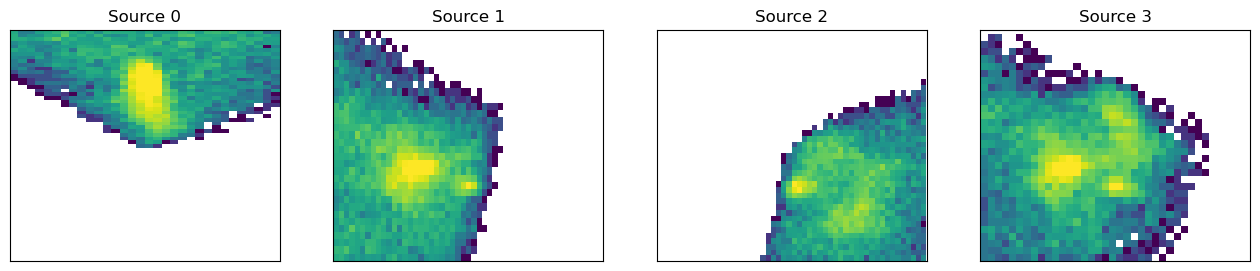

In [61]:
VMIN = 1.0
VMAX = 1.e2

fig = plt.figure(figsize=(4*NCOMP, 3))
for i, source in enumerate(sources):
    ax = plt.subplot(100 + 10*NCOMP + i + 1)
    _ = ax.hist2d(source['x'], source['y'], bins=BINX, cmap='viridis', norm=LogNorm(vmin=VMIN, vmax=VMAX))
    ax.set_title(f'Source {i}')
    ax.set_xlim(XMIN, XMAX)
    ax.set_ylim(YMIN, YMAX)
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)


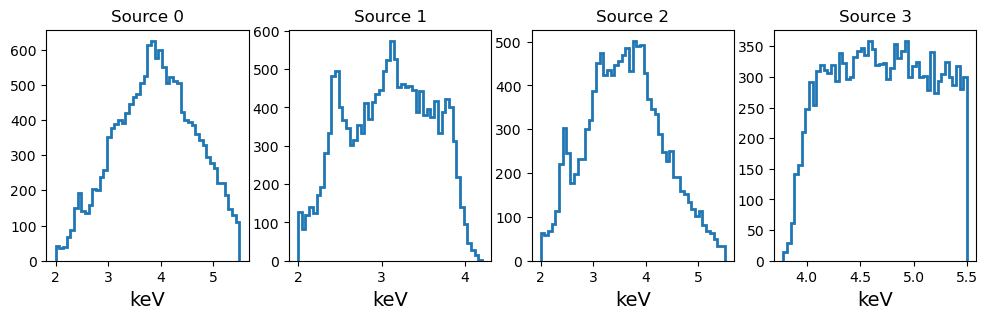

In [62]:
plt.figure(figsize=(3*NCOMP, 3))
for i, source in enumerate(sources):
    ax = plt.subplot(100 + 10*NCOMP + i + 1)
    _ = ax.hist(source['energy']/1.e3, bins=BINE, histtype='step', lw=2)
    ax.set_title(f'Source {i}')
    ax.set_xlabel('keV', size=14)

## Define loss functions

In [63]:
import pywt

def my_loss_function_F(model, target):
    mse_loss = torch.mean((model - target)**2)
    return mse_loss

def my_loss_function_poisson(model, target):
    # Assuming model and target are tensors
    model_copy = model.clone()
    model_copy[model == 0] = 1.e-10
    return torch.sum(model_copy - target * torch.log(model_copy))   # Poisson loss

def anscombe_transform(x):
    """Anscombe transform for Poisson noise stabilization"""
    return 2 * torch.sqrt(x + 3/8)

def inverse_anscombe(x):
    """Inverse Anscombe transform"""
    return torch.clamp((x/2)**2 - 3/8, min=0)

## Image smoothness [i.e, lp norm on the gradient]
def image_variation_loss(x: torch.Tensor) -> torch.Tensor:
    # for shape (H, W)
    tv_h = torch.sum(torch.abs(x[1:, :] - x[:-1, :]))
    tv_w = torch.sum(torch.abs(x[:, 1:] - x[:, :-1]))
    return tv_h + tv_w

## Image smoothness [i.e, lp norm on the gradient]
def spectral_variation_loss(x: torch.Tensor) -> torch.Tensor:
    # for shape (H, W)
    tv_h = torch.sum(torch.abs(x[1:] - x[:-1]))
    return tv_h


def sparsity(x: torch.Tensor) -> torch.Tensor:
    # L1 norm
    return torch.sum(torch.abs(x))

# p = 1 --> close to Laplacean, more blocky, allows more outliers
# p = 2 --> close to Gaussian, more smooth and wave-like
# Google explanation of lp-norms for more
def lp_norm(x, p=1) -> torch.Tensor:
    assert p >= 1
    assert p <= 2
    return torch.sum(torch.abs(x + 1.e-8)**p)**(1/p)


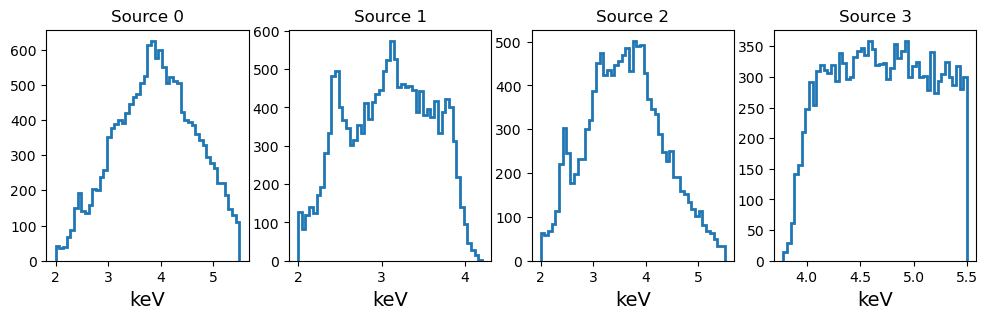

In [64]:
plt.figure(figsize=(3*NCOMP, 3))
for i, source in enumerate(sources):
    ax = plt.subplot(100 + 10*NCOMP + i + 1)
    _ = ax.hist(source['energy']/1.e3, bins=BINE, histtype='step', lw=2)
    ax.set_title(f'Source {i}')
    ax.set_xlabel('keV', size=14)

## wavelet inspection code ##

import pywt

wavelet = 'db2'        # good default
level = 3             # depends on cube size


keys= ['aad', 'ada', 'daa', 'add', 'dad', 'dda', 'ddd']

wavelets = pywt.wavelist(kind='discrete')

fig, axs = plt.subplots(len(wavelets), len(keys) + 1, figsize=(10, len(wavelets) * 2))
for a, wave in enumerate(wavelets):

    coeffs = pywt.wavedecn(
        spectral_cube,
        wavelet=wave,
        level=level,
        mode='periodization'
    )

    axs[a, 0].imshow(spectral_cube[0], origin='lower', cmap='viridis')
    axs[a, 0].set_title("Original cube")

    for i, key in enumerate(keys):
        cD = coeffs[level][key]
        e_slice = cD.shape[0] // 2
        axs[a, i+1].imshow(cD[e_slice], origin='lower', cmap='viridis')
        axs[a, i+1].set_title(f"{key}_{wave}")

    plt.title(f"{wave}")
plt.show()



In [65]:
# additional wavelet loss = extra hyperparameters
# NOTE: this is very slow, perhaps replace with convolution
def wavelet_loss(x: torch.Tensor) -> torch.Tensor:
    coeffs = pywt.wavedecn(
        spectral_cube,
        wavelet='dmey',
        level=1,
        mode='periodization'
    )
    loss = 0.0
    
    # weights are diff wavelet decomps, with "d" signifying the derivative
    # so it's x, y, energy
    # where d is sharper edges
    # this should be tweaked! which is most important?
    weights = {
        'aad': 1.0,
        'ada': 1.0,
        'daa': 1.0,
        'add': 1.0,
        'dad': 1.0,
        'dda': 1.0,
        'ddd': 1.0, 
    }

    # select only a couple of important ones
    keys = ['add', 'ddd']
    
    for key in keys:
        c = coeffs[-1][key]
        loss += weights[key] * np.mean(np.abs(c))

    return loss


## Gaussian Mixture Models ##

In [66]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
scaled_df = std_scaler.fit_transform(low_e_subset[['x', 'y', 'energy']])

NCOMP = 3
gmm = GaussianMixture(
    n_components=NCOMP,
    covariance_type='full',   # most flexible; try 'diag' if you want faster
    random_state=0
)

gmm.fit(scaled_df)

,"n_components n_components: int, default=1The number of mixture components.",3
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",0


In [ ]:
probs = gmm.predict_proba(scaled_df)  # shape: (N_points, NCOMP)
print("Means (scaled):")
print(gmm.means_)

print("Covariances:")
print(gmm.covariances_)

print("BIC:", gmm.bic(scaled_df))
print("AIC:", gmm.aic(scaled_df))

Means (scaled):
[[ 0.15164094  1.1239532   0.19935672]
 [-0.75140125 -0.46528724 -0.10170322]
 [ 0.8250201  -0.6604257  -0.09167193]]
Covariances:
[[[ 0.8997994  -0.01482851 -0.01602525]
  [-0.01482851  0.2846458  -0.1027359 ]
  [-0.01602525 -0.10273591  0.99196804]]

 [[ 0.35242936  0.02240485  0.06518743]
  [ 0.02240485  0.41750973  0.01849624]
  [ 0.06518744  0.01849624  0.98135966]]

 [[ 0.5173397  -0.08092111  0.00567732]
  [-0.08092111  0.42678574  0.04007324]
  [ 0.00567732  0.04007325  0.96661496]]]
BIC: 498909.49997946015
AIC: 498648.54803848267


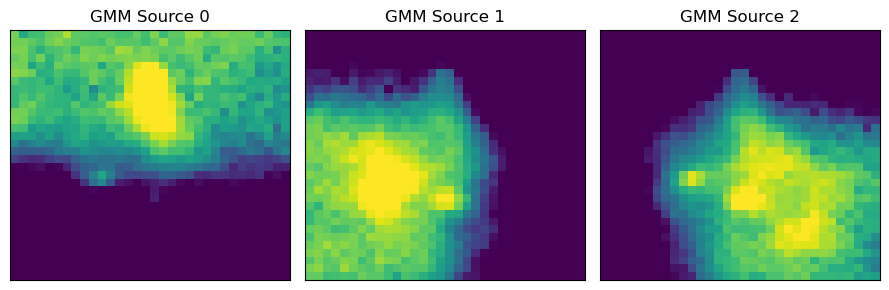

In [68]:
VMIN = 1.0
VMAX = 1e2

fig = plt.figure(figsize=(3 * NCOMP, 3))

for i in range(NCOMP):
    ax = plt.subplot(100 + 10 * NCOMP + i + 1)

    h = ax.hist2d(
        low_e_subset['x'],
        low_e_subset['y'],
        bins=(BINX, BINY),
        range=[[XMIN, XMAX], [YMIN, YMAX]],
        weights=probs[:, i],
        cmap='viridis',
        norm=LogNorm(vmin=VMIN, vmax=VMAX)
    )

    ax.set_title(f'GMM Source {i}')
    ax.set_xlim(XMIN, XMAX)
    ax.set_ylim(YMIN, YMAX)
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)

plt.tight_layout()


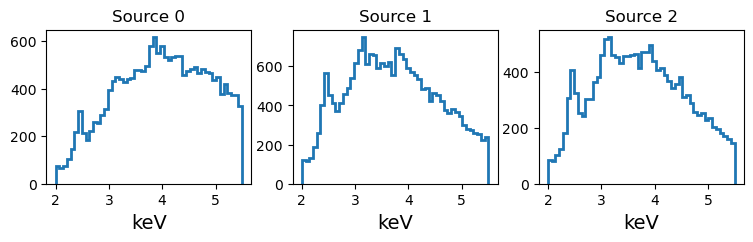

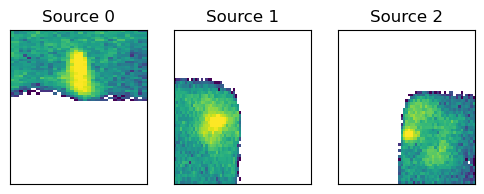

In [71]:
plt.figure(figsize=(3*NCOMP, 2))
spec_hist = np.zeros((NCOMP, BINE))

sources_gmm = []
for i in range(NCOMP):
    mask = probs[:, i] > 0.5
    sources_gmm.append(low_e_subset[mask])

for i, source in enumerate(sources_gmm):
    ax = plt.subplot(100 + 10*NCOMP + i + 1)
    spec_hist[i], _ = np.histogram(
        low_e_subset['energy'],
        bins=BINE,
        range=(EMIN, EMAX),
        weights=probs[:, i]
    )
    _ = ax.hist(source['energy']/1.e3, bins=BINE, histtype='step', lw=2)
    ax.set_title(f'Source {i}')
    ax.set_xlabel('keV', size=14)

fig = plt.figure(figsize=(2*NCOMP, 2))
for i, source in enumerate(sources_gmm):
    ax = plt.subplot(100 + 10*NCOMP + i + 1)
    _ = ax.hist2d(source['x'], source['y'], bins=(BINX, BINY), cmap='viridis', norm=LogNorm(vmin=VMIN, vmax=VMAX))
    ax.set_title(f'Source {i}')
    ax.set_xlim(XMIN, XMAX)
    ax.set_ylim(YMIN, YMAX)
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)

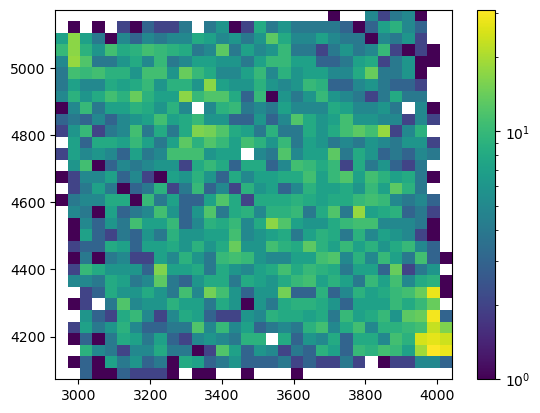

In [72]:
# Load in blank sky
BG_FILE = "6639_c0.fits"
hdul = fits.open(BG_FILE)
bg_data = hdul[1].data

cols = ['energy', 'x', 'y', 'ccd_id']

bg_df = Table([bg_data[c] for c in cols], names=cols).to_pandas()
bg_subset = bg_df[(bg_df['energy'] > EMIN) & (bg_df['energy'] < EMAX)]


_ = plt.hist2d(bg_subset['x'], bg_subset['y'], bins=BINX, cmap='viridis', norm=LogNorm())
plt.colorbar()

In [73]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu') # use GPU

n_bands, nx_pixels, ny_pixels = spectral_cube_tensor.shape
x_range = (XMIN, XMAX)
y_range = (YMIN, YMAX)

S_gmm = np.zeros((NCOMP + 1, nx_pixels, ny_pixels))

for i in range(NCOMP):
    mask = probs[:, i] > 0.5
    H, xedges, yedges = np.histogram2d(
        low_e_subset[mask]['x'],
        low_e_subset[mask]['y'],
        bins=[nx_pixels, ny_pixels],
        range=[x_range, y_range],
        weights=probs[mask][:, i]
    )


    S_gmm[i] = H


H_blank, xedges, yedges = np.histogram2d(
    bg_subset['x'], bg_subset['y'],
    bins=[nx_pixels, ny_pixels],
    range=[x_range, y_range]
)

S_gmm[i+1] = H_blank

# pytorch section

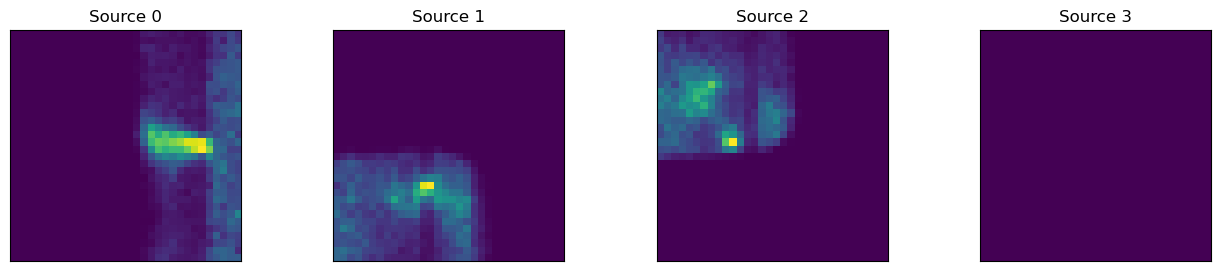

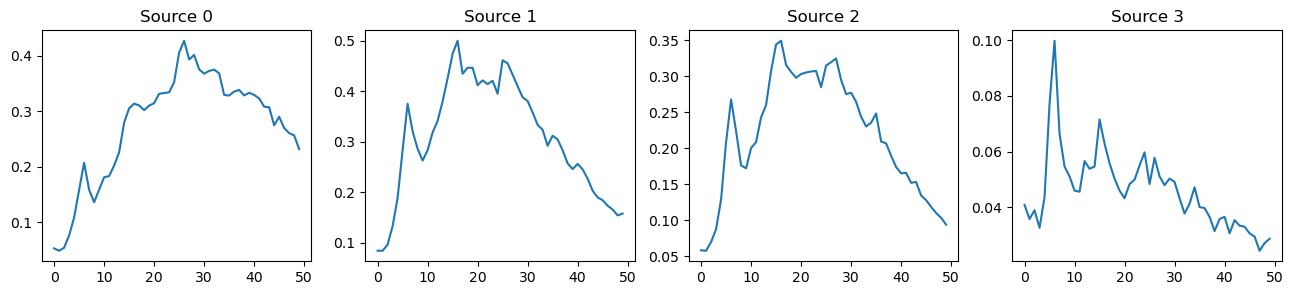

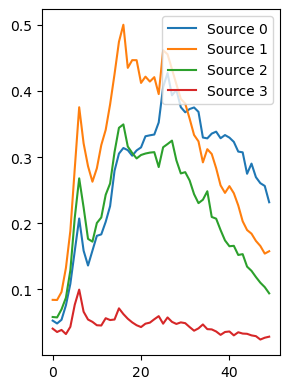

In [188]:
from tqdm import tqdm
from scipy.ndimage import gaussian_filter1d

# INITIALIZATIONS

n_comp = 3

n_bands, nx_pixels, ny_pixels = spectral_cube_tensor.shape
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu') # use GPU

# Initialize A and S with the KMeans clusters

# S
S = torch.nn.functional.normalize(torch.from_numpy(S_gmm), dim=(0,1)).requires_grad_().to(device)

# plotting check
NCOMP_TRUE = NCOMP + 1
fig = plt.figure(figsize=(4*NCOMP_TRUE, 3))
for i, source in enumerate(S.detach().numpy()):
    ax = plt.subplot(100 + 10*NCOMP_TRUE + i + 1)
    ax.imshow(source, origin="lower")
    ax.set_title(f'Source {i}')
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)

# A
spec_hist = np.zeros((NCOMP_TRUE, n_bands))
bg_hist, edges = np.histogram(bg_subset['energy'], bins=n_bands, range=(EMIN, EMAX))
bg_hist = gaussian_filter1d((bg_hist),0.5)
bg_hist = torch.tensor(0.5 * bg_hist)

for i in range(NCOMP):
    mask = probs[:, i] > 0.5
    spec_hist[i], _ = np.histogram(
        low_e_subset[mask]['energy'],
        bins=n_bands,
        range=(EMIN, EMAX),
        weights=probs[mask][:, i]
    )

# normalization magic (maintain different maximums)
spec_hist = gaussian_filter1d(spec_hist,0.5)
max_spec = np.max(spec_hist)
spec_hist = torch.from_numpy(spec_hist)
#maxes = torch.max(spec_hist, dim=1).values
#maxes = torch.nn.functional.normalize(torch.atleast_3d(maxes)).squeeze()
#spec_hist = torch.nn.functional.normalize(spec_hist) * maxes.unsqueeze(1)

spec_hist[i + 1] = bg_hist
spec_hist = spec_hist / (2 * max_spec)
A = spec_hist.T.requires_grad_().to(device)

# 1 max 300, 2 max 400, 3 max 250, 4 max 140

fig = plt.figure(figsize=(4*NCOMP_TRUE, 3))
for i, source in enumerate(A.T.detach().numpy()):
    ax = plt.subplot(100 + 10*NCOMP_TRUE + i + 1)
    ax.plot(source)
    ax.set_title(f'Source {i}')

plt.figure(figsize=(NCOMP, 4))
for i in range(4):
    plt.plot(A.detach().numpy()[:,i], label=f'Source {i}')

plt.legend()
plt.tight_layout()


In [170]:
## Image smoothness [i.e, lp norm on the gradient]
scaled_spec = torch.softmax(spec_hist, dim=1)
def spectral_min_change(x: torch.Tensor) -> torch.Tensor:
    # for shape (H, W)
    tv_h = torch.sum(torch.abs(scaled_spec - x))
    return tv_h

def starlet_loss(cube: torch.Tensor) -> torch.Tensor:
    cube_np = cube.detach().cpu().numpy()
    coeffs = pys.Starlet_Forward3D(cube_np,J=4)[:,:,:,1:3]
    loss = np.sum(np.abs(coeffs))
    return loss

  0%|          | 0/2000 [00:00<?, ?it/s]

Step 0, Loss: 10.6961
Loss Composition: starlet (0.0006341727312695724), sparsity (0.0003706898132196236)
Magnitudes: A (4.689969419913224), S (39.00614680114045)


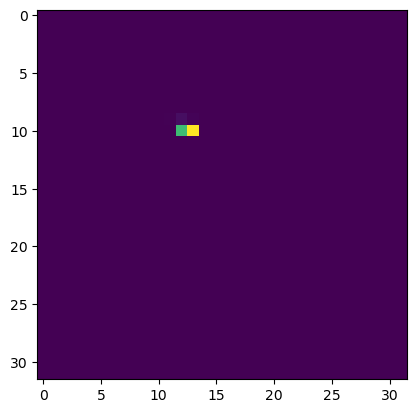

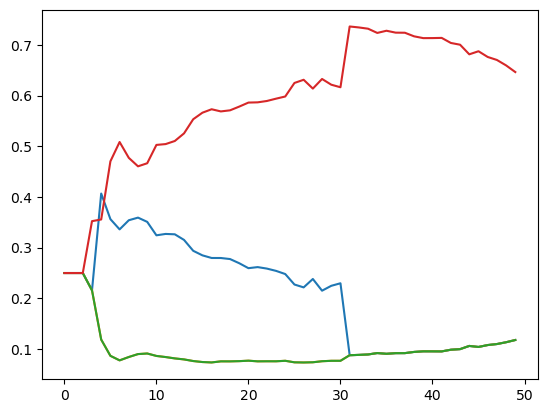

 25%|██▍       | 491/2000 [00:05<00:16, 93.84it/s] 

Step 500, Loss: 10.5211
Loss Composition: starlet (0.0), sparsity (0.0)
Magnitudes: A (4.968517631051377), S (48.18687772285432)


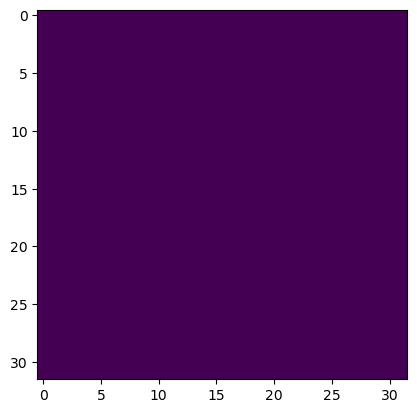

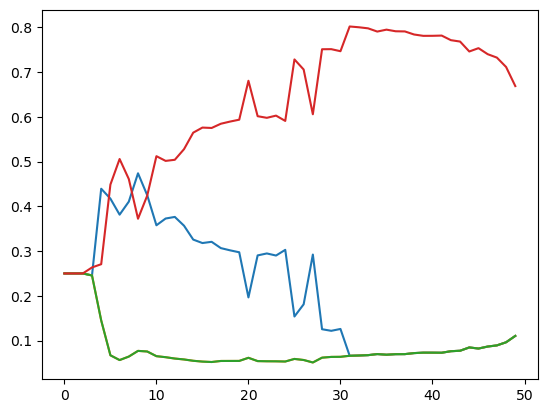

 50%|████▉     | 996/2000 [00:11<00:13, 74.88it/s]

Step 1000, Loss: 10.4234
Loss Composition: starlet (0.0), sparsity (0.0)
Magnitudes: A (5.125849784726256), S (54.15812445949388)


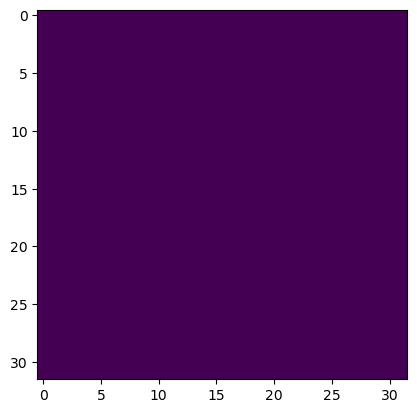

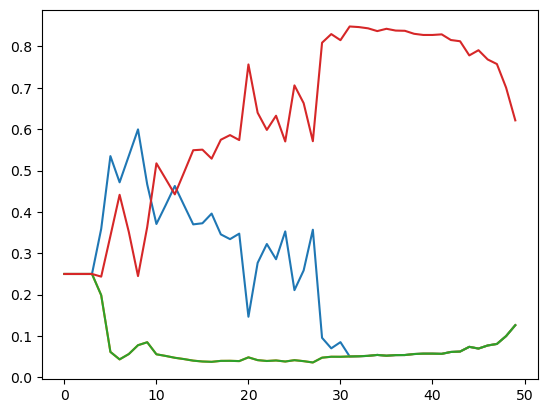

 75%|███████▍  | 1497/2000 [00:18<00:06, 74.39it/s]

Step 1500, Loss: 10.3565
Loss Composition: starlet (0.0), sparsity (0.0)
Magnitudes: A (5.207704309458844), S (58.696311138064864)


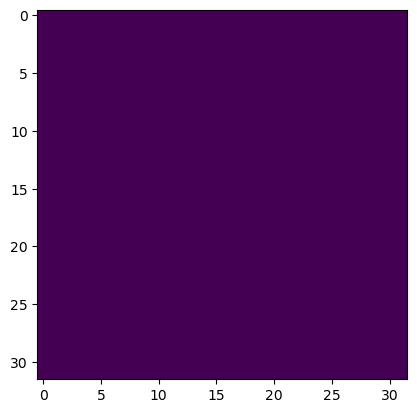

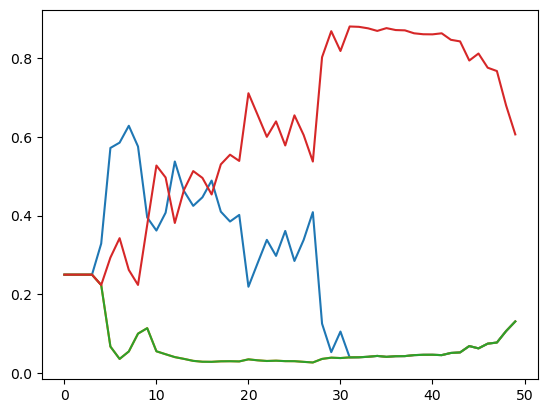

100%|██████████| 2000/2000 [00:26<00:00, 76.71it/s]


In [192]:

lr = 8.e-4
optimizer = torch.optim.Adam([S, A], lr=lr)

# initialize loss values for plot
loss_values = []

max_iter = 2000
lambda_smooth = 1.
lambda_spec = 2.
lambda_sparsity = 50.
lambda_starlet = 1.

for i in tqdm(range(max_iter)):
        A_pos = torch.clamp(A, min=0)  # non-negativity
        A_pos = torch.softmax(A_pos, dim=1)  # sum-to-one constraint
        S_pos = torch.clamp(S, min=0)    # non-negativity

        reconstruction = torch.einsum('bc,cxy->bxy', A_pos, S_pos) # TODO: learn einsum shorthand
    
        # Try poisson loss function
        loss = torch.log(my_loss_function_poisson(reconstruction, spectral_cube_tensor.to(device)))
        
        star_loss = 0
        overlap_loss = 0
        for j in range(n_comp):
            component_j = torch.einsum('c,xy->cxy', A_pos[:, j], S_pos[j])
            star_loss = starlet_loss(component_j)
            
            #loss += sparsity(S_pos[j,:,:]) * lambda_sparsity  # encourage sparsity
            #loss += image_variation_loss(S_pos[j, :, :]) * lambda_smooth
            
            # spectral smoothness (maybe unnecessary)
            #loss += spectral_min_change(A_pos[:,j]) * lambda_spec
            
            # cross-source spatial sparsity
            for ij in range(j + 1, n_comp):
                overlap_loss += torch.sum(S_pos[ij] * S_pos[ij])
        loss += star_loss * lambda_starlet     
        loss += lambda_sparsity * overlap_loss
        
        loss.backward()
        
        optimizer.step()
        optimizer.zero_grad()
        if i % 500 == 0:
            print(f"Step {i}, Loss: {loss.item():.4f}")
            print(f"Loss Composition: starlet ({lambda_starlet * star_loss / loss}), sparsity ({lambda_sparsity * overlap_loss / loss})")
            print(f"Magnitudes: A ({torch.norm(A_pos)}), S ({torch.norm(S_pos)})")
            loss_values.append(loss.item())

            plt.imshow(S_pos.detach().cpu().numpy()[1,:,:,])
            plt.show()
            plt.plot(A_pos.detach().cpu().numpy()[:,3], label=f'3')
            plt.plot(A_pos.detach().cpu().numpy()[:,2], label=f'2')
            plt.plot(A_pos.detach().cpu().numpy()[:,1], label=f'1')
            plt.plot(A_pos.detach().cpu().numpy()[:,0], label=f'0')
            plt.show()

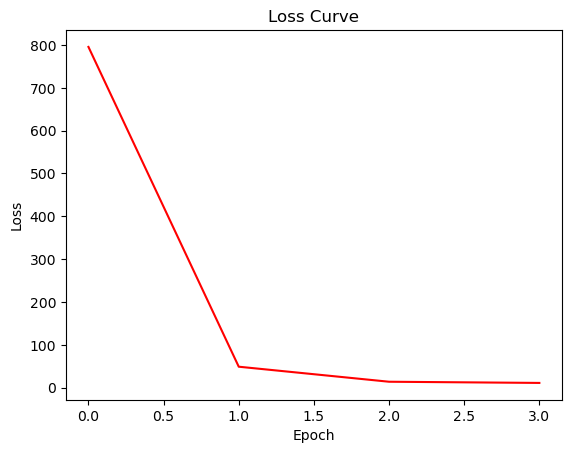

In [190]:
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.plot(np.array(loss_values), 'r')

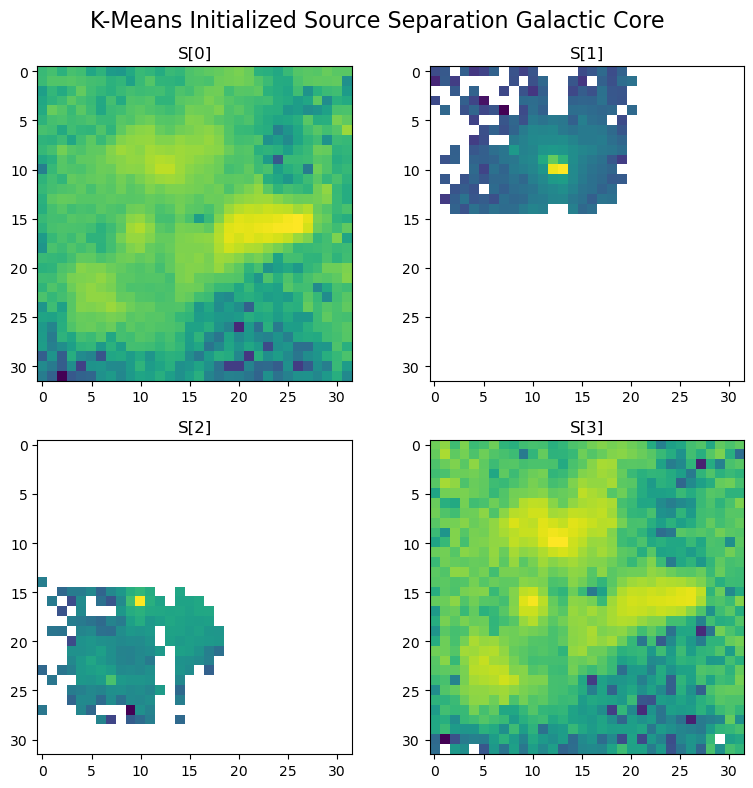

In [191]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(8, 8))
gs = GridSpec(2, 2)
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(S_pos.detach().cpu().numpy()[0, :, :], cmap='viridis', norm=LogNorm())
ax1.set_title('S[0]')
ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(S_pos.detach().cpu().numpy()[1, :, :], cmap='viridis', norm=LogNorm(),alpha=1.0)
ax2.set_title('S[1]')
ax3 = fig.add_subplot(gs[1, 0])
ax3.imshow(S_pos.detach().cpu().numpy()[2, :, :], cmap='viridis', norm=LogNorm())
ax3.set_title('S[2]')
ax4 = fig.add_subplot(gs[1, 1])
im = ax4.imshow(S_pos.detach().cpu().numpy()[3, :, :], cmap='viridis', norm=LogNorm())
ax4.set_title('S[3]')
fig.suptitle("K-Means Initialized Source Separation Galactic Core", fontsize=16)

plt.tight_layout()

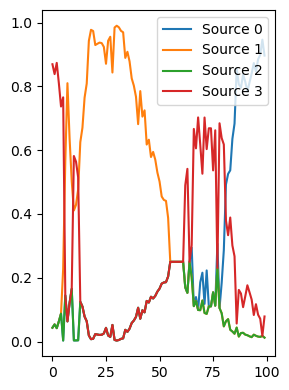

In [297]:
plt.figure(figsize=(NCOMP, 4))
for i in range(4):
    plt.plot(A_pos.detach().cpu().numpy()[:,i], label=f'Source {i}')

plt.legend()
plt.tight_layout()

## TODO ##

- GMM instead of KMeans for initialization
- split the image around the 5KeV spectral area (use below 5keV)
- hold initialized spectra fixed and fit for the images
    - use blanksky for 6639, skip the background flares (you don't need the gti, use ccd_id= either 0,1,2,3)
    - execute using blanksy script, don't need image
- three objects are bottom left (Sag A*), top (pulsar wind nebula), bottom right (IRS 13 star cluster)
- make some slides explaining each step: img + spectra, etc for